In [57]:
import os
import pandas as pd
import tiktoken
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/ahmed/Desktop/msc-24/TND')
from utils import load_json, save_json

In [30]:
def read_data():
    df_1 = pd.read_csv(
        "/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_1.csv"
    )
    list_1 = df_1["file_path"].to_list()

    df_2 = pd.read_csv(
        "/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_2.csv"
    )
    list_2 = df_2["file_path"].to_list()

    df_3 = pd.read_csv(
        "/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_3.csv"
    )
    list_3 = df_3["file_path"].to_list()

    df_4 = pd.read_csv(
        "/Users/ahmed/Desktop/msc-24/TND/kc_classification_data/pre_cutoff_data/df_4.csv"
    )
    list_4 = df_4["file_path"].to_list()

    return list_1, list_2, list_3, list_4

In [34]:
list_1, list_2, list_3, list_4 = read_data()
all_files = list_1 + list_2 + list_3 + list_4


data_path = "/Users/ahmed/Desktop/msc-24/ECHR/echr-processed"

In [37]:
encoding = tiktoken.encoding_for_model("gpt-4o-mini")
def count_tokens(txt):
    return len(encoding.encode(txt))

In [50]:
tokens_count = {}
for file in all_files:
    case_path = os.path.join(data_path, file)
    case = load_json(case_path)
    case_id = case["itemid"]
    facts = case["facts"]
    law = case["law"]
    facts_tokens = count_tokens(facts)
    law_tokens = count_tokens(law)
    facts_law_tokens = facts_tokens + law_tokens
    tokens_count[case_id] = {"facts_tokens": facts_tokens, "law_tokens": law_tokens, "facts_law_tokens": facts_law_tokens}

In [51]:
df_tokens = pd.DataFrame(tokens_count).T 

In [52]:
df_tokens

,facts_tokens,law_tokens,facts_law_tokens
001-228016,2641,7465,10106
001-220960,1449,5214,6663
001-220484,9291,8154,17445
001-219943,2053,4003,6056
001-219333,8145,32278,40423
...,...,...,...
001-226568,40,994,1034
001-226575,1276,2083,3359
001-226580,624,1258,1882
001-226576,38,438,476


In [22]:
def importance_to_binary_label(importance):
    importance = int(importance)
    if importance == 1:
        return 1
    else:
        return 0

def category_to_binary_label(category):
    if category == "KEY CASE":
        #print('1 == ', category)
        return 1
    else:
        #print('0 == ', category)
        return 0

def get_df(output_dir = '/Users/ahmed/Desktop/msc-24/TND/CoT/task_1/CoT_binary/results'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        item_id = result.split("_")[-1].split(".")[0]
        #if int(result_data["importance"]) == 1:
        #    print(result_data["importance"], result_data["cot_facts"]['classification'])
        cot_facts_classification = category_to_binary_label(result_data["cot_facts"]['classification'])
        cot_law_classification = category_to_binary_label(result_data["cot_law"]['classification'])
        cot_facts_law_classification = category_to_binary_label(result_data["cot_facts_law"]['classification'])
        importance = int(result_data["importance"])
        ground_truth = importance_to_binary_label(importance)

        data.append(
            {
                "item_id": item_id,
                "facts": cot_facts_classification,
                "law": cot_law_classification,
                "facts_law": cot_facts_law_classification,
                "ground_truth": ground_truth,
                "importance": importance
            }
        )

    df = pd.DataFrame(data)
    return df


In [23]:
df_results = get_df()

In [25]:
df_results['facts_results'] = df_results['facts'] == df_results['ground_truth']
df_results['law_results'] = df_results['law'] == df_results['ground_truth']
df_results['facts_law_results'] = df_results['facts_law'] == df_results['ground_truth']

In [27]:
df_results = df_results[['item_id', 'facts_results', 'law_results', 'facts_law_results']]

In [28]:
df_results

,item_id,facts_results,law_results,facts_law_results
0,001-197098,False,True,False
1,001-218302,False,False,False
2,001-122893,True,False,False
3,001-217624,True,False,True
4,001-184525,True,True,True
...,...,...,...,...
495,001-221369,True,False,False
496,001-118738,True,False,False
497,001-228675,True,True,True
498,001-207360,False,True,True


In [46]:
df_tokens

,facts_tokens,law_tokens
001-228016,2641,7465
001-220960,1449,5214
001-220484,9291,8154
001-219943,2053,4003
001-219333,8145,32278
...,...,...
001-226568,40,994
001-226575,1276,2083
001-226580,624,1258
001-226576,38,438


In [53]:
df_all = df_results.merge(df_tokens, left_on='item_id', right_index=True)

In [54]:
df_all

,item_id,facts_results,law_results,facts_law_results,facts_tokens,law_tokens,facts_law_tokens
0,001-197098,False,True,False,11641,13634,25275
1,001-218302,False,False,False,1962,4608,6570
2,001-122893,True,False,False,6588,17684,24272
3,001-217624,True,False,True,2076,5231,7307
4,001-184525,True,True,True,17569,20610,38179
...,...,...,...,...,...,...,...
495,001-221369,True,False,False,291,3333,3624
496,001-118738,True,False,False,4793,6983,11776
497,001-228675,True,True,True,47,897,944
498,001-207360,False,True,True,2746,9782,12528


In [65]:
df_all.dtypes

item_id              object
facts_results          bool
law_results            bool
facts_law_results      bool
facts_tokens          int64
law_tokens            int64
facts_law_tokens      int64
dtype: object

In [55]:
# distribution of facts tokens for correct and incorrect predictions
df_all.groupby('facts_results')['facts_tokens'].describe()

,count,mean,std,min,25%,50%,75%,max
facts_results,,,,,,,,
False,156.0,9653.275641,11188.973330,55.0,3575.5,6823.0,10967.5,75614.0
True,343.0,4320.725948,6572.248964,20.0,55.0,2448.0,5876.5,73999.0


In [56]:
df_all.groupby('facts_law_results')['facts_law_tokens'].describe()

,count,mean,std,min,25%,50%,75%,max
facts_law_results,,,,,,,,
False,226.0,18184.176991,15415.187141,2593.0,9162.0,14224.0,22303.5,118314.0
True,273.0,11321.388278,15589.153595,417.0,1034.0,6458.0,14771.0,109090.0


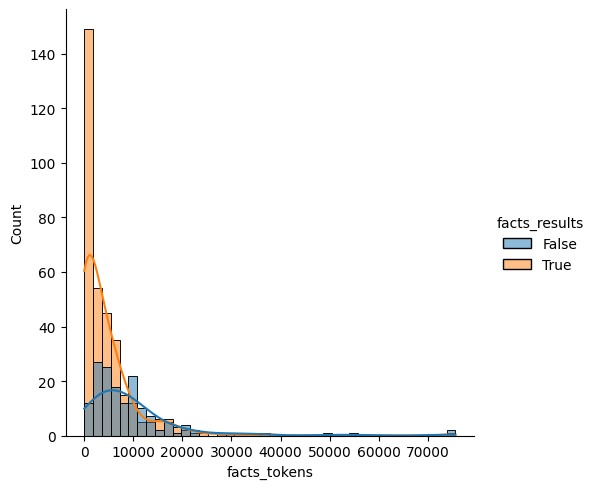

In [71]:
# graph the distribution of facts tokens for correct and incorrect predictions

sns.displot(data = df_all, x= "facts_tokens", kde=True, hue="facts_results")

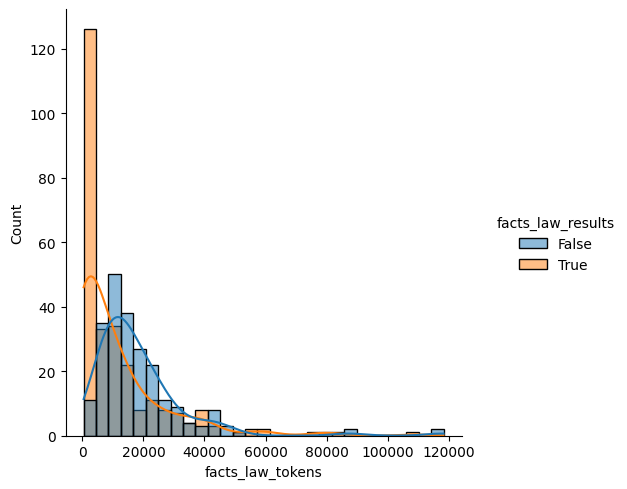

In [70]:
sns.displot(data = df_all, x= "facts_law_tokens", kde=True, hue="facts_law_results")

In [73]:

from scipy.stats import ttest_ind

# Step 1: Add token difference column
df_all['token_difference'] = df_all['facts_law_tokens'] - df_all['facts_tokens']

# Step 2: Descriptive Statistics
stats = df_all.groupby('facts_law_results')['facts_law_tokens'].agg(['mean', 'std', 'count'])
print("Descriptive statistics for facts_law_tokens by accuracy:\n", stats)

# Step 3: Statistical Test
correct_tokens = df_all[df_all['facts_law_results'] == True]['facts_law_tokens']
incorrect_tokens = df_all[df_all['facts_law_results'] == False]['facts_law_tokens']

t_stat, p_value = ttest_ind(correct_tokens, incorrect_tokens)
print(f"T-test results: t-statistic = {t_stat}, p-value = {p_value}")

Descriptive statistics for facts_law_tokens by accuracy:
                            mean           std  count
facts_law_results                                   
False              18184.176991  15415.187141    226
True               11321.388278  15589.153595    273
T-test results: t-statistic = -4.919899600496433, p-value = 1.1792576439823277e-06


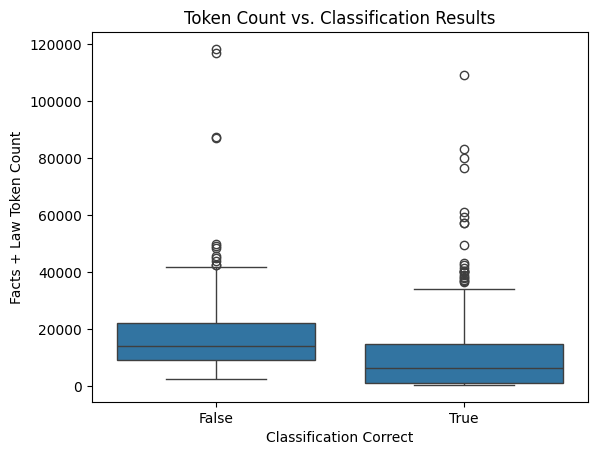

In [75]:
# Token count vs. accuracy
sns.boxplot(x='facts_law_results', y='facts_law_tokens', data=df_all)
plt.title("Token Count vs. Classification Results")
plt.xlabel("Classification Correct")
plt.ylabel("Facts + Law Token Count")
plt.show()


In [77]:
df = df_results.merge(df_tokens, left_on='item_id', right_index=True)

In [78]:
df

,item_id,facts_results,law_results,facts_law_results,facts_tokens,law_tokens,facts_law_tokens
0,001-197098,False,True,False,11641,13634,25275
1,001-218302,False,False,False,1962,4608,6570
2,001-122893,True,False,False,6588,17684,24272
3,001-217624,True,False,True,2076,5231,7307
4,001-184525,True,True,True,17569,20610,38179
...,...,...,...,...,...,...,...
495,001-221369,True,False,False,291,3333,3624
496,001-118738,True,False,False,4793,6983,11776
497,001-228675,True,True,True,47,897,944
498,001-207360,False,True,True,2746,9782,12528


In [79]:
# Assuming your dataframe is named 'df'
df['law_tokens'] = df['facts_law_tokens'] - df['facts_tokens']
df['result_changed'] = (df['facts_results'] == True) & (df['facts_law_results'] == False)

In [80]:
changed_cases = df[df['result_changed']]

# Calculate the average token difference for these cases
average_law_tokens_changed = changed_cases['law_tokens'].mean()
print(f"Average additional tokens in law section for cases where result changed: {average_law_tokens_changed}")

Average additional tokens in law section for cases where result changed: 8298.834586466166


In [81]:
# Calculate the average token difference across all cases
average_law_tokens_all = df['law_tokens'].mean()
print(f"Average additional tokens in law section across all cases: {average_law_tokens_all}")

Average additional tokens in law section across all cases: 8441.769539078156


/var/folders/dl/d24xg2c11gx7r5rs5b6kd_780000gn/T/ipykernel_7230/2536484632.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['law_tokens'], changed_cases['law_tokens']], labels=['All Cases', 'Changed Cases'])


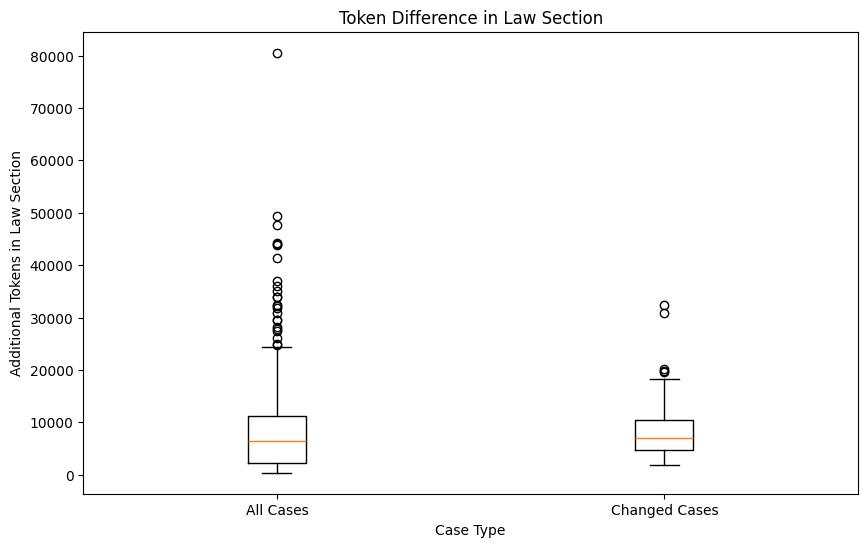

In [82]:
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(10, 6))
plt.boxplot([df['law_tokens'], changed_cases['law_tokens']], labels=['All Cases', 'Changed Cases'])
plt.title('Token Difference in Law Section')
plt.xlabel('Case Type')
plt.ylabel('Additional Tokens in Law Section')
plt.show()

In [83]:
import scipy.stats as stats

# Perform a t-test
t_stat, p_value = stats.ttest_ind(df['law_tokens'], changed_cases['law_tokens'], equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.24255548809214814, P-value: 0.8084878472958233
